# Generate Goban Images with AI

Generate realistic Go board photos using Google Gemini / Imagen models
for training data augmentation. Generation logic lives in `moku.generate`.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

from dotenv import load_dotenv
from google import genai

from moku.generate import generate_batch, make_prompt

load_dotenv()

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
OUT_DIR = Path("data/generated")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Client ready")
print(f"Output: {OUT_DIR.resolve()}")

Client ready
Output: /Users/hadim/Code/libs/moku/notebooks/data/generated


## Sample prompts

Preview the randomized prompt builder.

In [6]:
for _ in range(3):
    prompt, size = make_prompt()
    print(f"[{size}] {prompt}\n")

[13×13] A photorealistic photograph of a real wooden Go board (goban) with a 13×13 grid, near the end with about 60-100 stones on the board. CRITICAL: every stone must be placed exactly centered on a grid intersection — never between lines. The round black and white stones sit precisely on the intersections of the grid. The photograph is taken from a gentle top-down angle, about 25 degrees from vertical, showing the ENTIRE board with ALL FOUR corners clearly visible in the frame. No part of the board is cropped or cut off. Soft diffused overhead light. The board sits on a tatami mat. The wooden board shows natural grain texture and the grid lines are clearly engraved. The stones are perfectly round, smooth, and slightly convex with a subtle shine. Sharp focus, high resolution. No text, watermarks, or overlays.

[19×19] A photorealistic photograph of a real wooden Go board (goban) with a 19×19 grid, with a few scattered groups of about 30-50 stones. CRITICAL: every stone must be placed 

## Generate images

Using Gemini 2.5 Flash Image by default. Switch `model` to try others
(e.g. `gemini-3.1-flash-image-preview`, `imagen-4.0-fast-generate-001`).

In [ ]:
saved = generate_batch(
    client,
    n=5,
    out_dir=OUT_DIR,
    model="gemini-3.1-flash-image-preview",
    prefix="generated",
    delay=2.0,
)

[gemini-3.1-flash-image-preview] 1/5 (9×9) ...
  Saved gemini25_0000.png ((1024, 1024))
[gemini-3.1-flash-image-preview] 2/5 (19×19) ...
  Saved gemini25_0001.png ((1024, 1024))
[gemini-3.1-flash-image-preview] 3/5 (9×9) ...
  Saved gemini25_0002.png ((1024, 1024))
[gemini-3.1-flash-image-preview] 4/5 (19×19) ...
  Saved gemini25_0003.png ((1024, 1024))
[gemini-3.1-flash-image-preview] 5/5 (19×19) ...
  Saved gemini25_0004.png ((1024, 1024))
Done — 5/5 images saved


## Visual inspection

Display all generated images in a grid.

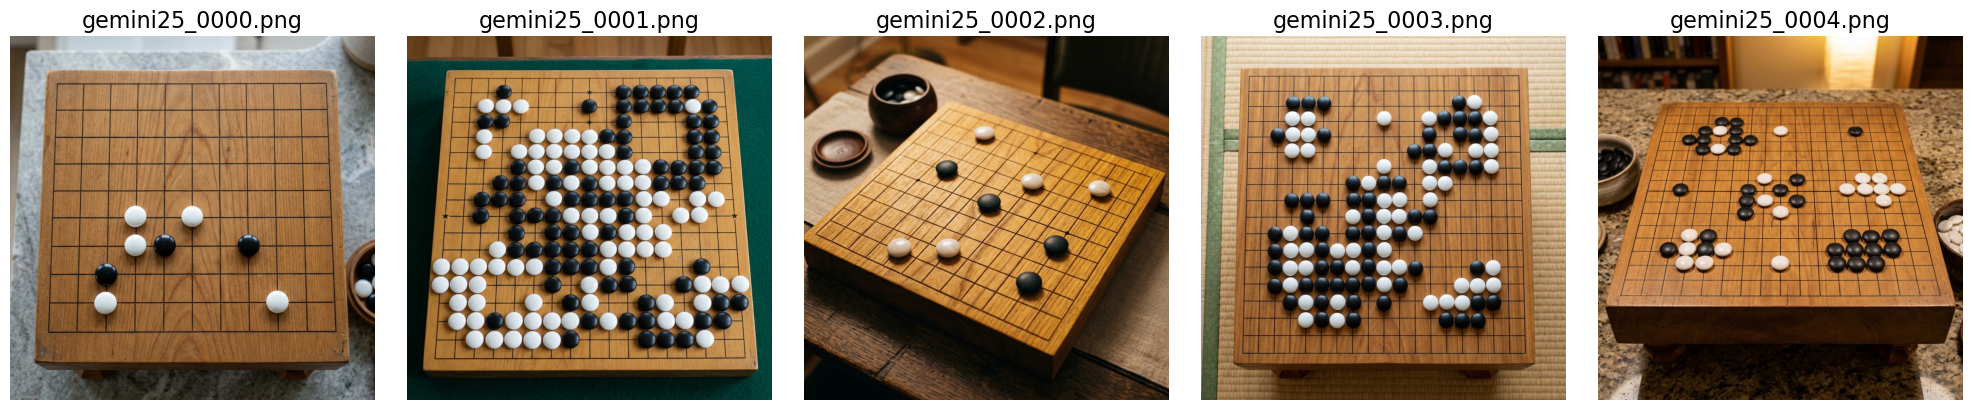

5 images in data/generated


In [9]:
import matplotlib.pyplot as plt
from PIL import Image

paths = sorted(OUT_DIR.glob("*.png"))
n = len(paths)
cols = min(5, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = [axes] if n == 1 else axes.flat
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.name, fontsize=16)
    ax.axis("off")
for ax in list(axes)[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"{n} images in {OUT_DIR}")

## Cost estimate

| Model | Cost/image | 100 images | 500 images | 1000 images |
|-------|-----------|------------|------------|-------------|
| Imagen 4 Fast | $0.02 | $2 | $10 | $20 |
| **Gemini 2.5 Flash Image** | **$0.039** | **$3.90** | **$19.50** | **$39** |
| Gemini 3.1 Flash Image | $0.067 | $6.70 | $33.50 | $67 |